In [1]:
import sys 
sys.path.insert(0, r"C:\ProjectsDannyDavis\VolatilityPredictionProject")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model

import statsmodels.api as sm

from utils.file_reader import read_file
from utils import plotting_functions as plot_func
from utils import returns_utils
from utils.File_Paths import raw_data_filepath

In [2]:
# importing price & returns data
returns_df = read_file(raw_data_filepath, r"SP500_price_data.parquet")[['simple_return']]

In [3]:
returns_df

,simple_return
date,
2010-01-05,0.003116
2010-01-06,0.000546
2010-01-07,0.004001
2010-01-08,0.002882
2010-01-11,0.001747
...,...
2025-12-24,0.003221
2025-12-26,-0.000304
2025-12-29,-0.003492


In [4]:
# fitting GARCH(1,1) model to data
    # (identified as having the lowest BIC in time_series_modelling.arch_model)

garch11_model = arch_model(returns_df * 100, # multiplying by 100 for better scale
                           mean='Zero',
                           vol='GARCH',
                           p=1,
                           q=1).fit(cov_type='robust')
print(garch11_model.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 2244923086.9970655
Iteration:      2,   Func. Count:     11,   Neg. LLF: 7246.845368515244
Iteration:      3,   Func. Count:     16,   Neg. LLF: 5926.864350315525
Iteration:      4,   Func. Count:     23,   Neg. LLF: 10165.433107964232
Iteration:      5,   Func. Count:     28,   Neg. LLF: 5202.579169741619
Iteration:      6,   Func. Count:     32,   Neg. LLF: 5202.543035675092
Iteration:      7,   Func. Count:     36,   Neg. LLF: 5202.542538958987
Iteration:      8,   Func. Count:     40,   Neg. LLF: 5202.542347169698
Iteration:      9,   Func. Count:     44,   Neg. LLF: 5202.542346275444
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5202.542346275444
            Iterations: 9
            Function evaluations: 44
            Gradient evaluations: 9
                       Zero Mean - GARCH Model Results                        
Dep. Variable:          simple_return   R-squared:              

In [5]:
# Collecting the standardised residuals
std_resid = pd.DataFrame(garch11_model.std_resid)

# Squaring residuals
std_resid['z_sq'] = std_resid['std_resid']**2

# joining returns df
std_resid = std_resid.merge(returns_df, how='inner', left_index=True, right_index=True)

# shifting returns (reflects yesterday's returns predicting residual vol today)
std_resid['lag_return'] = std_resid['simple_return'].shift(1)

# sign bias -> binary variable indicating positive or negative return
std_resid['sign_bias'] = np.where(std_resid['lag_return']>0, 1, 0)

# negative size bias
std_resid['neg_size_bias'] = np.where(std_resid['lag_return']>0, 0, std_resid['lag_return'])

# positive size bias
std_resid['pos_size_bias'] = np.where(std_resid['lag_return']>0, std_resid['lag_return'], 0)

std_resid = std_resid.dropna()

In [6]:
std_resid

,std_resid,z_sq,simple_return,lag_return,sign_bias,neg_size_bias,pos_size_bias
date,,,,,,,
2010-01-06,0.060656,0.003679,0.000546,0.003116,1,0.000000,0.003116
2010-01-07,0.479219,0.229650,0.004001,0.000546,1,0.000000,0.000546
2010-01-08,0.363193,0.131909,0.002882,0.004001,1,0.000000,0.004001
2010-01-11,0.232849,0.054218,0.001747,0.002882,1,0.000000,0.002882
2010-01-12,-1.326321,1.759127,-0.009381,0.001747,1,0.000000,0.001747
...,...,...,...,...,...,...,...
2025-12-24,0.420692,0.176981,0.003221,0.004550,1,0.000000,0.004550
2025-12-26,-0.041783,0.001746,-0.000304,0.003221,1,0.000000,0.003221
2025-12-29,-0.509592,0.259684,-0.003492,-0.000304,0,-0.000304,0.000000


In [7]:
configs=[{'type':'scatter',
     'data':std_resid,
     'x':'neg_size_bias', 
     'y':'z_sq',
     'ylabel':'Squared Standardised Residual',
     'xlabel':'Neg Size Bias',
     'colors':[plot_func.color_palette_teal_blue['Classic Teal'][0]],
     'title':'Negative Returns'},
     {'type':'scatter',
     'data':std_resid,
     'x':'pos_size_bias', 
     'y':'z_sq',
     'ylabel':'Squared Standardised Residual',
     'xlabel':'Pos Size Bias',
     'colors':[plot_func.color_palette_teal_blue['Cerulean Teal'][0]],
     'title':'Positive Returns'},
     ]

(<Figure size 1400x450 with 2 Axes>,
 array([[<Axes: title={'center': 'Negative Returns'}, xlabel='Neg Size Bias', ylabel='Squared Standardised Residual'>,
         <Axes: title={'center': 'Positive Returns'}, xlabel='Pos Size Bias', ylabel='Squared Standardised Residual'>]],
       dtype=object))

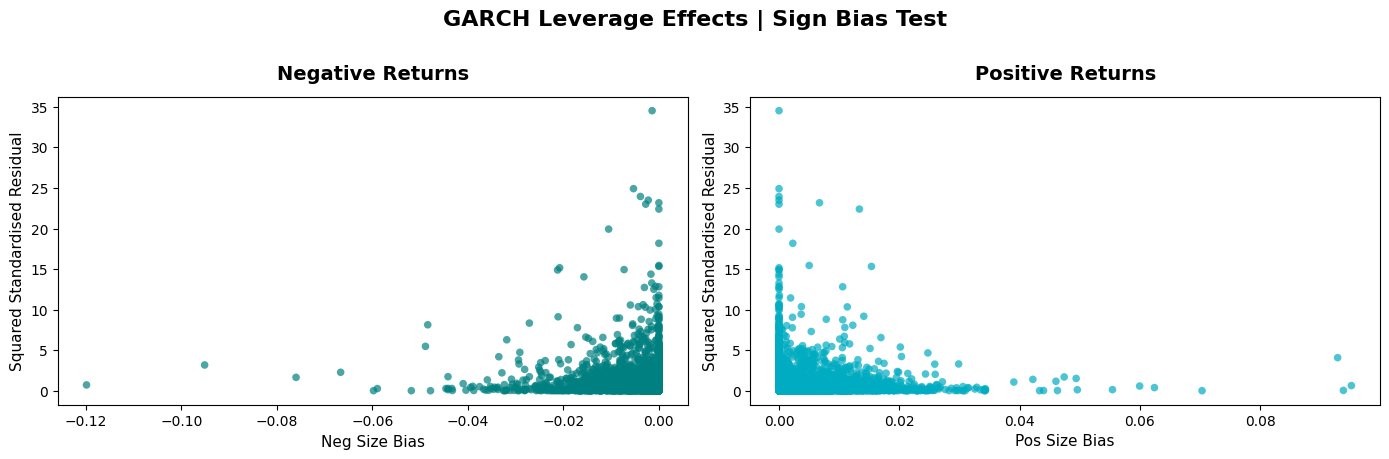

In [8]:
plot_func.plot_subplots(plot_configs=configs, suptitle='GARCH Leverage Effects | Sign Bias Test')

In [9]:
# Individual Test - Sign Bias

sign_bias_con = sm.add_constant(std_resid['sign_bias'])
sign_bias_model = sm.OLS(endog=std_resid['z_sq'], exog=sign_bias_con).fit(cov_type='HC0')
print(sign_bias_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     40.18
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           2.57e-10
Time:                        18:53:38   Log-Likelihood:                -8396.5
No. Observations:                4022   AIC:                         1.680e+04
Df Residuals:                    4020   BIC:                         1.681e+04
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2215      0.054     22.451      0.0

In [10]:
# Individual Test - Negative Size Bias

neg_size_bias_con = sm.add_constant(std_resid['neg_size_bias'])
neg_size_model = sm.OLS(endog=std_resid['z_sq'], exog=neg_size_bias_con).fit(cov_type='HC0')
print(neg_size_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     10.90
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           0.000969
Time:                        18:53:38   Log-Likelihood:                -8412.7
No. Observations:                4022   AIC:                         1.683e+04
Df Residuals:                    4020   BIC:                         1.684e+04
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.9521      0.033     28.881

In [11]:
# Individual Test - Positive Size Bias

pos_size_bias_con = sm.add_constant(std_resid['pos_size_bias'])
pos_size_model = sm.OLS(endog=std_resid['z_sq'], exog=pos_size_bias_con).fit(cov_type='HC0')
print(pos_size_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     23.15
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           1.55e-06
Time:                        18:53:39   Log-Likelihood:                -8408.0
No. Observations:                4022   AIC:                         1.682e+04
Df Residuals:                    4020   BIC:                         1.683e+04
Df Model:                           1                                         
Covariance Type:                  HC0                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.0799      0.038     28.484

In [12]:
# Joint F-Test Using All Three Regressors

all_exog_con = sm.add_constant(std_resid[['sign_bias','pos_size_bias','neg_size_bias']])
model_all = sm.OLS(endog=std_resid['z_sq'], exog=all_exog_con).fit(cov_type='HC0')
print(model_all.summary())

                            OLS Regression Results                            
Dep. Variable:                   z_sq   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     14.34
Date:                Sat, 11 Jul 2026   Prob (F-statistic):           2.72e-09
Time:                        18:53:39   Log-Likelihood:                -8395.8
No. Observations:                4022   AIC:                         1.680e+04
Df Residuals:                    4018   BIC:                         1.682e+04
Df Model:                           3                                         
Covariance Type:                  HC0                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2313      0.072     17.037

In [13]:
f_test = model_all.f_test('sign_bias = 0, neg_size_bias = 0, pos_size_bias = 0')

In [14]:
print(f"F-Test Stat: {f_test.fvalue}")
print(f"F-Test P-value: {f_test.pvalue}")

F-Test Stat: 14.340404049010155
F-Test P-value: 2.716629957715653e-09


## Leverage Effect — Summary Chart

Groups days by the *prior* day's return (down / flat / up) and plots the average squared standardised residual that follows. A well-specified symmetric GARCH would predict this to be flat at 1.0 regardless of prior return — instead it steps down cleanly from down-days to up-days, visualising the inverse (leverage) relationship confirmed by the sign-bias test above.

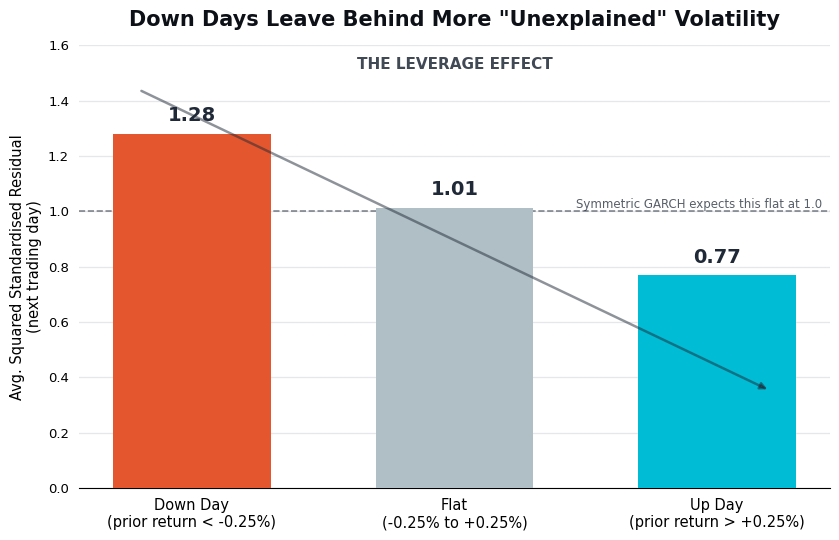

In [33]:
# ─────────────────────────────────────────────
# Leverage Effect — Summary Chart
# ─────────────────────────────────────────────

leverage_bins = [-np.inf, -0.0025, 0.0025, np.inf]
leverage_labels = ['Down Day\n(prior return < -0.25%)', 'Flat\n(-0.25% to +0.25%)', 'Up Day\n(prior return > +0.25%)']
std_resid['prior_day_type'] = pd.cut(std_resid['lag_return'], bins=leverage_bins, labels=leverage_labels)

leverage_summary = std_resid.groupby('prior_day_type', observed=True)['z_sq'].mean()

fig, ax = plt.subplots(figsize=(8.5, 5.5))
fig.patch.set_facecolor('white')

bar_colors = ['#E4572E', '#B0BEC5', '#00BCD4']  # red (down) -> grey (flat) -> teal (up)
bars = ax.bar(leverage_summary.index, leverage_summary.values, color=bar_colors, width=0.6, zorder=3)
ax.bar_label(bars, fmt='%.2f', padding=6, fontsize=14, fontweight='bold', color='#1F2937')

# reference line: a well-specified symmetric GARCH expects z_sq to average ~1.0 regardless of prior return
ax.axhline(1.0, color='#1F2937', linewidth=1.2, linestyle='--', alpha=0.55, zorder=2)
ax.text(0.99, 1.0, 'Symmetric GARCH expects this flat at 1.0', fontsize=8.5, color='#1F2937',
        alpha=0.75, ha='right', va='bottom', transform=ax.get_yaxis_transform())

# arrow + label calling out the inverse relationship
ax.annotate('', xy=(0.92, 0.22), xytext=(0.08, 0.90), xycoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>', color='#1F2937', lw=1.8, alpha=0.5))
ax.text(0.5, 0.94, 'THE LEVERAGE EFFECT', fontsize=11, fontweight='bold', color='#1F2937',
        alpha=0.85, ha='center', va='bottom', transform=ax.transAxes)

ax.set_title('Down Days Leave Behind More "Unexplained" Volatility', fontsize=15, fontweight='bold', pad=14, color='#0D1117')
ax.set_ylabel('Avg. Squared Standardised Residual\n(next trading day)', fontsize=10.5)
ax.set_xlabel('')
ax.set_ylim(0, 1.6)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.yaxis.grid(True, color='#E5E7EB', linewidth=0.9, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(left=False, bottom=False)
ax.tick_params(axis='x', labelsize=10.5)
ax.tick_params(axis='y', labelsize=9.5)

plt.tight_layout()
plt.show()